In [52]:
import pandas as pd
import numpy as np

In [54]:
df = pd.read_csv('D:\\Lending\\accepted_2007_to_2018Q4.csv')

C:\Users\HP\AppData\Local\Temp\ipykernel_696\546142228.py:1: DtypeWarning: Columns (0: id, 1: desc, 2: next_pymnt_d, 3: verification_status_joint, 4: sec_app_earliest_cr_line, 5: hardship_type, 6: hardship_reason, 7: hardship_status, 8: hardship_start_date, 9: hardship_end_date, 10: payment_plan_start_date, 11: hardship_loan_status, 12: debt_settlement_flag_date, 13: settlement_status, 14: settlement_date) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('D:\\Lending\\accepted_2007_to_2018Q4.csv')


In [55]:
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [58]:
print(df.shape)
df.info(memory_usage='deep')

(2260701, 151)
<class 'pandas.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Columns: 151 entries, id to settlement_term
dtypes: float64(113), object(1), str(37)
memory usage: 3.1 GB


In [60]:
null_pct = df.isnull().mean().sort_values(ascending=False) * 100

In [62]:
null_summary = pd.DataFrame({
    'null_pct': null_pct.round(2),
    'dtype': df.dtypes
})


In [8]:
pd.set_option('display.max_rows', None)
print(null_summary)

                                            null_pct    dtype
acc_now_delinq                                  0.00  float64
acc_open_past_24mths                            2.21  float64
addr_state                                      0.00      str
all_util                                       38.32  float64
annual_inc                                      0.00  float64
annual_inc_joint                               94.66  float64
application_type                                0.00      str
avg_cur_bal                                     3.11  float64
bc_open_to_buy                                  3.32  float64
bc_util                                         3.37  float64
chargeoff_within_12_mths                        0.01  float64
collection_recovery_fee                         0.00  float64
collections_12_mths_ex_med                      0.01  float64
debt_settlement_flag                            0.00      str
debt_settlement_flag_date                      98.49      str
deferral

In [64]:
df['title'].nunique()

63154

In [66]:
df['purpose'].value_counts()

purpose
debt_consolidation    1277877
credit_card            516971
home_improvement       150457
other                  139440
major_purchase          50445
medical                 27488
small_business          24689
car                     24013
vacation                15525
moving                  15403
house                   14136
wedding                  2355
renewable_energy         1445
educational               424
Name: count, dtype: int64

In [68]:
df['url'].nunique()

2260668

In [70]:
df['application_type'].value_counts()

application_type
Individual    2139958
Joint App      120710
Name: count, dtype: int64

In [72]:
joint_rows = df[df['application_type'] == 'Joint App']

print((joint_rows['annual_inc_joint'] >= joint_rows['annual_inc']).mean())

joint_rows[['annual_inc', 'annual_inc_joint']].describe()

1.0


,annual_inc,annual_inc_joint
count,1.207100e+05,1.207100e+05
mean,6.011094e+04,1.236246e+05
std,5.245647e+04,7.416135e+04
min,0.000000e+00,5.693510e+03
25%,3.500000e+04,8.340000e+04
50%,5.200000e+04,1.100000e+05
75%,7.500000e+04,1.479950e+05
max,6.240000e+06,7.874821e+06


In [74]:
# ---- Step 1: Engineer combined/coalesced features FIRST (before dropping their sources) ----
df['combined_annual_inc'] = df['annual_inc_joint'].fillna(df['annual_inc'])
df['combined_dti'] = df['dti_joint'].fillna(df['dti'])
df['combined_fico_low'] = df['sec_app_fico_range_low'].fillna(df['fico_range_low'])
df['combined_fico_high'] = df['sec_app_fico_range_high'].fillna(df['fico_range_high'])
df['is_joint'] = (df['application_type'] == 'Joint App').astype(int)

# ---- Step 2: Post-issuance leakage columns (payment history, hardship/settlement flags & events) ----
df['is_joint'] = (df['application_type'] == 'Joint App').astype(int)

# ---- Step 2: Post-issuance leakage columns (payment history, hardship/settlement flags & events) ----
df['is_joint'] = (df['application_type'] == 'Joint App').astype(int)

# ---- Step 2: Post-issuance leakage columns (payment history, hardship/settlement flags & events) ----
leakage_cols = [
    'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee',
    'recoveries', 'collection_recovery_fee', 'out_prncp', 'out_prncp_inv',
    'last_pymnt_d', 'last_pymnt_amnt', 'last_credit_pull_d',
    'last_fico_range_high', 'last_fico_range_low', 'next_pymnt_d',
    'debt_settlement_flag', 'debt_settlement_flag_date', 'hardship_flag',
    'payment_plan_start_date', 'pymnt_plan', 'orig_projected_additional_accrued_interest',
    # detailed hardship/settlement columns (99%+ null, only exist post-default/distress)
    'hardship_amount', 'hardship_dpd', 'hardship_end_date', 'hardship_last_payment_amount',
    'hardship_length', 'hardship_loan_status', 'hardship_payoff_balance_amount',
    'hardship_reason', 'hardship_start_date', 'hardship_status', 'hardship_type', 'deferral_term',
    'settlement_amount', 'settlement_date', 'settlement_percentage', 'settlement_status', 'settlement_term'
]

# ---- Step 3: Identifiers / redundant text columns ----
id_cols = ['id', 'member_id', 'url', 'zip_code', 'title', 'emp_title']

# ---- Step 4: Now-redundant joint/individual columns (superseded by combined_* + is_joint) ----
joint_related_drop = [
    'annual_inc', 'dti', 'fico_range_low', 'fico_range_high',
    'annual_inc_joint', 'dti_joint', 'revol_bal_joint', 'verification_status_joint',
    'application_type',  # redundant with is_joint
    'sec_app_fico_range_low', 'sec_app_fico_range_high', 'sec_app_earliest_cr_line',
    'sec_app_inq_last_6mths', 'sec_app_mort_acc', 'sec_app_open_acc', 'sec_app_revol_util',
    'sec_app_open_act_il', 'sec_app_num_rev_accts', 'sec_app_chargeoff_within_12_mths',
    'sec_app_collections_12_mths_ex_med', 'sec_app_mths_since_last_major_derog'
]

all_drop_cols = leakage_cols + id_cols + joint_related_drop
df = df.drop(columns=[c for c in all_drop_cols if c in df.columns])

print(df.shape)


(2260701, 91)


C:\Users\HP\AppData\Local\Temp\ipykernel_696\587481510.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['combined_annual_inc'] = df['annual_inc_joint'].fillna(df['annual_inc'])
C:\Users\HP\AppData\Local\Temp\ipykernel_696\587481510.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['combined_dti'] = df['dti_joint'].fillna(df['dti'])
C:\Users\HP\AppData\Local\Temp\ipykernel_696\587481510.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has 

In [76]:
df['policy_code'].value_counts()

policy_code
1.0    2260668
Name: count, dtype: int64

In [78]:
df.dtypes.value_counts()

float64    76
str        14
int32       1
Name: count, dtype: int64

In [50]:
list(df.columns)

['loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'term',
 'int_rate',
 'installment',
 'grade',
 'sub_grade',
 'emp_length',
 'home_ownership',
 'verification_status',
 'issue_d',
 'loan_status',
 'desc',
 'purpose',
 'addr_state',
 'delinq_2yrs',
 'earliest_cr_line',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'initial_list_status',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'policy_code',
 'acc_now_delinq',
 'tot_coll_amt',
 'tot_cur_bal',
 'open_acc_6m',
 'open_act_il',
 'open_il_12m',
 'open_il_24m',
 'mths_since_rcnt_il',
 'total_bal_il',
 'il_util',
 'open_rv_12m',
 'open_rv_24m',
 'max_bal_bc',
 'all_util',
 'total_rev_hi_lim',
 'inq_fi',
 'total_cu_tl',
 'inq_last_12m',
 'acc_open_past_24mths',
 'avg_cur_bal',
 'bc_open_to_buy',
 'bc_util',
 'chargeoff_within_12_mths',
 'delinq_amnt',
 'mo_sin_old_il_acct',
 'mo_sin_old_rev_tl_op',
 'mo_sin_rcnt_rev_tl_op',
 

In [80]:
# 1. How often do funded_amnt / funded_amnt_inv equal loan_amnt?
print("funded_amnt == loan_amnt:      ", (df['funded_amnt'] == df['loan_amnt']).mean())
print("funded_amnt_inv == loan_amnt:  ", (df['funded_amnt_inv'] == df['loan_amnt']).mean())
print("funded_amnt_inv == funded_amnt:", (df['funded_amnt_inv'] == df['funded_amnt']).mean())

# 2. Look at the rows where they actually diverge
diff = df[df['loan_amnt'] != df['funded_amnt']]
print(f"\nRows where funded_amnt != loan_amnt: {len(diff)} ({len(diff)/len(df):.4%})")
diff[['loan_amnt', 'funded_amnt', 'funded_amnt_inv']].head(10)

# 3. Does the divergence itself correlate with default?
df['funding_shortfall'] = df['loan_amnt'] - df['funded_amnt']
print("\nShortfall > 0 rate by loan_status:")
print(df.groupby('loan_status')['funding_shortfall'].apply(lambda s: (s > 0).mean()))


funded_amnt == loan_amnt:       0.9990719692697089
funded_amnt_inv == loan_amnt:   0.9329703485777199
funded_amnt_inv == funded_amnt: 0.9331428614398808

Rows where funded_amnt != loan_amnt: 2098 (0.0928%)

Shortfall > 0 rate by loan_status:
loan_status
Charged Off                                            0.001273
Current                                                0.000003
Default                                                0.000000
Does not meet the credit policy. Status:Charged Off    0.057819
Does not meet the credit policy. Status:Fully Paid     0.048793
Fully Paid                                             0.001466
In Grace Period                                        0.000000
Late (16-30 days)                                      0.000000
Late (31-120 days)                                     0.000000
Name: funding_shortfall, dtype: float64


In [82]:
df.groupby('sub_grade')['int_rate'].agg(['mean', 'std', 'nunique'])

,mean,std,nunique
sub_grade,,,
A1,5.600265,0.392642,12
A2,6.552337,0.350171,19
A3,7.094535,0.304612,22
A4,7.560239,0.328957,23
A5,8.195006,0.376874,23
B1,9.078554,0.711623,32
B2,9.974970,0.634192,28
B3,10.705015,0.738832,29
B4,11.372778,0.679236,28


In [84]:
pass2_drop_cols = [
    'funded_amnt',
    'grade', 'sub_grade', 'int_rate',
    'installment'
]

df = df.drop(columns=[c for c in pass2_drop_cols if c in df.columns])
print(df.shape)  # expect: (2260668, 85)

(2260701, 87)


In [88]:
df.columns

Index(['loan_amnt', 'funded_amnt_inv', 'term', 'emp_length', 'home_ownership',
       'verification_status', 'issue_d', 'loan_status', 'desc', 'purpose',
       'addr_state', 'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths',
       'mths_since_last_delinq', 'mths_since_last_record', 'open_acc',
       'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
       'initial_list_status', 'collections_12_mths_ex_med',
       'mths_since_last_major_derog', 'acc_now_delinq', 'tot_coll_amt',
       'tot_cur_bal', 'open_acc_6m', 'open_act_il', 'open_il_12m',
       'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util',
       'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util',
       'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m',
       'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util',
       'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct',
       'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl',
       'mort_acc', 'm

In [86]:
df = df.drop(columns=['policy_code'])
print(df.shape)  # expect: (rows, 85)

(2260701, 86)


In [91]:
df.head()

,loan_amnt,funded_amnt_inv,term,emp_length,home_ownership,verification_status,issue_d,loan_status,desc,purpose,...,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,disbursement_method,combined_annual_inc,combined_dti,combined_fico_low,combined_fico_high,is_joint,funding_shortfall
0,3600.0,3600.0,36 months,10+ years,MORTGAGE,Not Verified,Dec-2015,Fully Paid,NaN,debt_consolidation,...,7746.0,2400.0,13734.0,Cash,55000.0,5.91,675.0,679.0,0,0.0
1,24700.0,24700.0,36 months,10+ years,MORTGAGE,Not Verified,Dec-2015,Fully Paid,NaN,small_business,...,39475.0,79300.0,24667.0,Cash,65000.0,16.06,715.0,719.0,0,0.0
2,20000.0,20000.0,60 months,10+ years,MORTGAGE,Not Verified,Dec-2015,Fully Paid,NaN,home_improvement,...,18696.0,6200.0,14877.0,Cash,71000.0,13.85,695.0,699.0,1,0.0
3,35000.0,35000.0,60 months,10+ years,MORTGAGE,Source Verified,Dec-2015,Current,NaN,debt_consolidation,...,52226.0,62500.0,18000.0,Cash,110000.0,17.06,785.0,789.0,0,0.0
4,10400.0,10400.0,60 months,3 years,MORTGAGE,Source Verified,Dec-2015,Fully Paid,NaN,major_purchase,...,95768.0,20300.0,88097.0,Cash,104433.0,25.37,695.0,699.0,0,0.0


In [95]:
df['desc'].nunique()

124500

In [99]:
df['desc'].sample(5)

16886      NaN
1199579    NaN
1052504    NaN
579319     NaN
1476567    NaN
Name: desc, dtype: str

In [101]:
df['desc'].isnull().mean()

0.9442363231581709

In [103]:
df['desc'].notnull() .sample()

1586842    False
Name: desc, dtype: bool

In [105]:
# Basic shape of the column
print("Null %:", df['desc'].isna().mean() * 100)
print("Unique non-null values:", df['desc'].nunique())
print("Total non-null rows:", df['desc'].notna().sum())

# What does the text actually look like?
print(df['desc'].dropna().sample(5, random_state=42).tolist())

# Length distribution — is this a sentence/paragraph, or short like title?
desc_lengths = df['desc'].dropna().str.len()
print(desc_lengths.describe())

# Does presence of a description (vs missing) correlate with default rate?
df['has_desc'] = df['desc'].notna().astype(int)
print(pd.crosstab(df['has_desc'], df['loan_status'], normalize='index'))

Null %: 94.42363231581709
Unique non-null values: 124500
Total non-null rows: 126065
["I've ended up with a few loans from different places, and with relatively poor interest rates in retrospect. I would like to have one convenient payment per month, and hopefully a better interest rate.  I am paying off a small personal loan, a bit of credit card balance, and a loan used to buy a Marimba One 5 octave marimba for my wife (a recent music graduate).   I have very good credit and steady income, I would just like to consolidate a few things.  Thanks for your consideration!", '  Borrower added on 10/29/13 > We have incurred a credit card loan over the past 10 yrs to Capital One.  The interest rate is high.  We want to pay the loan but not all the interest that Capital One charges.  We got into this debt helping my parents and brother.<br>', ' 385521 added on 10/17/09 > I plan to use this money to pay off credit cards and consolidate debt.  After this I will close my accounts.  I am a teache

In [107]:
df = df.drop(columns=['desc', 'has_desc'])
print(df.shape)

(2260701, 85)


In [109]:
df.columns

Index(['loan_amnt', 'funded_amnt_inv', 'term', 'emp_length', 'home_ownership',
       'verification_status', 'issue_d', 'loan_status', 'purpose',
       'addr_state', 'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths',
       'mths_since_last_delinq', 'mths_since_last_record', 'open_acc',
       'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
       'initial_list_status', 'collections_12_mths_ex_med',
       'mths_since_last_major_derog', 'acc_now_delinq', 'tot_coll_amt',
       'tot_cur_bal', 'open_acc_6m', 'open_act_il', 'open_il_12m',
       'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util',
       'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util',
       'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m',
       'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util',
       'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct',
       'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl',
       'mort_acc', 'mths_sinc

In [111]:
# Confirm the formula: is it exactly loan_amnt - funded_amnt_inv?
implied = df['loan_amnt'] - df['funded_amnt_inv']
print("Matches loan_amnt - funded_amnt_inv:", (df['funding_shortfall'] == implied).mean())

# Basic distribution
print(df['funding_shortfall'].describe())
print("Zero shortfall (fully investor-funded) %:", (df['funding_shortfall'] == 0).mean() * 100)

# Does shortfall size relate to loan_status? (same check we ran for funded_amnt earlier)
df['has_shortfall'] = (df['funding_shortfall'] > 0).astype(int)
print(pd.crosstab(df['has_shortfall'], df['loan_status'], normalize='index'))

Matches loan_amnt - funded_amnt_inv: 0.9331428614398808
count    2.260668e+06
mean     5.267171e+00
std      2.033111e+02
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      2.115000e+04
Name: funding_shortfall, dtype: float64
Zero shortfall (fully investor-funded) %: 99.90719692697088
loan_status    Charged Off   Current   Default  \
has_shortfall                                    
0                 0.118753  0.388875  0.000018   
1                 0.165617  0.001453  0.000000   

loan_status    Does not meet the credit policy. Status:Charged Off  \
has_shortfall                                                        
0                                                       0.000317     
1                                                       0.021308     

loan_status    Does not meet the credit policy. Status:Fully Paid  Fully Paid  \
has_shortfall                                                                   
0                       

In [113]:
df = df.drop(columns=['funding_shortfall', 'has_shortfall'])
print(df.shape)


(2260701, 84)


In [117]:
df['sec_app_*'].nunique()

KeyError: 'sec_app_*'

In [119]:

from sklearn.metrics import roc_auc_score

# Binarize target: adjust this to match your actual encoding
target = (df['loan_status'] == 'Charged Off').astype(int)  # or however you've binarized it

leftover_cols = [c for c in df.columns if c not in ['loan_status', 'issue_d', 'earliest_cr_line']]

screen = []
for col in leftover_cols:
    s = df[col]
    if s.dtype.kind in 'ifb':  # numeric
        valid = s.notna()
        if valid.sum() > 100 and target[valid].nunique() > 1:
            auc = roc_auc_score(target[valid], s[valid])
            auc = max(auc, 1 - auc)  # direction-agnostic
        else:
            auc = None
        screen.append({
            'col': col, 'null_pct': s.isna().mean()*100,
            'nunique': s.nunique(), 'univariate_auc': auc
        })

screen_df = pd.DataFrame(screen).sort_values('univariate_auc', ascending=False)
print(screen_df.head(20))

                     col   null_pct  nunique  univariate_auc
71    combined_fico_high   0.001460       62        0.597147
70     combined_fico_low   0.001460       62        0.597147
33        bc_open_to_buy   3.316140    91500        0.587873
31  acc_open_past_24mths   2.214490       57        0.583988
24           open_rv_24m  38.313868       50        0.581983
59    num_tl_op_past_12m   3.110053       33        0.574859
30          inq_last_12m  38.313912       48        0.574405
26              all_util  38.323555      188        0.573309
66        total_bc_limit   2.214490    20309        0.571753
61      percent_bc_gt_75   3.335779      284        0.568671
34               bc_util   3.366389     1494        0.566815
69          combined_dti   0.001460     4889        0.566175
68   combined_annual_inc   0.001637    94183        0.565108
23           open_rv_12m  38.313868       29        0.563685
3         inq_last_6mths   0.002787       28        0.562584
22               il_util

In [123]:
high_null_cols = ['open_rv_24m', 'inq_last_12m', 'all_util', 'open_rv_12m', 'open_acc_6m', 'il_util']
for col in high_null_cols:
    df['issue_year'] = pd.to_datetime(df['issue_d']).dt.year
    null_by_year = df.groupby('issue_year')[col].apply(lambda s: s.isna().mean())
    print(f"\n{col} — null rate by issue year:")
    print(null_by_year)


C:\Users\HP\AppData\Local\Temp\ipykernel_696\2024002478.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['issue_year'] = pd.to_datetime(df['issue_d']).dt.year



open_rv_24m — null rate by issue year:
issue_year
2007.0    1.000000
2008.0    1.000000
2009.0    1.000000
2010.0    1.000000
2011.0    1.000000
2012.0    1.000000
2013.0    1.000000
2014.0    1.000000
2015.0    0.949247
2016.0    0.000140
2017.0    0.000000
2018.0    0.000000
Name: open_rv_24m, dtype: float64


C:\Users\HP\AppData\Local\Temp\ipykernel_696\2024002478.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['issue_year'] = pd.to_datetime(df['issue_d']).dt.year



inq_last_12m — null rate by issue year:
issue_year
2007.0    1.000000
2008.0    1.000000
2009.0    1.000000
2010.0    1.000000
2011.0    1.000000
2012.0    1.000000
2013.0    1.000000
2014.0    1.000000
2015.0    0.949247
2016.0    0.000143
2017.0    0.000000
2018.0    0.000000
Name: inq_last_12m, dtype: float64


C:\Users\HP\AppData\Local\Temp\ipykernel_696\2024002478.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['issue_year'] = pd.to_datetime(df['issue_d']).dt.year


...


open_rv_12m — null rate by issue year:
issue_year
2007.0    1.000000
2008.0    1.000000
2009.0    1.000000
2010.0    1.000000
2011.0    1.000000
2012.0    1.000000
2013.0    1.000000
2014.0    1.000000
2015.0    0.949247
2016.0    0.000140
2017.0    0.000000
2018.0    0.000000
Name: open_rv_12m, dtype: float64


C:\Users\HP\AppData\Local\Temp\ipykernel_696\2024002478.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['issue_year'] = pd.to_datetime(df['issue_d']).dt.year



open_acc_6m — null rate by issue year:
issue_year
2007.0    1.000000
2008.0    1.000000
2009.0    1.000000
2010.0    1.000000
2011.0    1.000000
2012.0    1.000000
2013.0    1.000000
2014.0    1.000000
2015.0    0.949247
2016.0    0.000143
2017.0    0.000000
2018.0    0.000000
Name: open_acc_6m, dtype: float64


C:\Users\HP\AppData\Local\Temp\ipykernel_696\2024002478.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['issue_year'] = pd.to_datetime(df['issue_d']).dt.year



il_util — null rate by issue year:
issue_year
2007.0    1.000000
2008.0    1.000000
2009.0    1.000000
2010.0    1.000000
2011.0    1.000000
2012.0    1.000000
2013.0    1.000000
2014.0    1.000000
2015.0    0.955789
2016.0    0.132155
2017.0    0.139308
2018.0    0.163201
Name: il_util, dtype: float64


In [125]:
high_null_cols = ['open_rv_24m', 'inq_last_12m', 'all_util', 'open_rv_12m', 'open_acc_6m', 'il_util']

for col in high_null_cols:
    flag = df[col].notna().astype(int)
    print(f"\n--- {col} ---")
    print(pd.crosstab(flag, df['loan_status'], normalize='index'))


--- open_rv_24m ---
loan_status  Charged Off   Current   Default  \
open_rv_24m                                    
0               0.171407  0.061162  0.000002   
1               0.086120  0.591839  0.000027   

loan_status  Does not meet the credit policy. Status:Charged Off  \
open_rv_24m                                                        
0                                                     0.000879     
1                                                     0.000000     

loan_status  Does not meet the credit policy. Status:Fully Paid  Fully Paid  \
open_rv_24m                                                                   
0                                                     0.002295     0.761146   
1                                                     0.000000     0.299382   

loan_status  In Grace Period  Late (16-30 days)  Late (31-120 days)  
open_rv_24m                                                          
0                   0.000884           0.000395         

In [127]:
# 1. See what we're removing
print(df['loan_status'].value_counts())

# 2. Apply the filter
closed_statuses = [
    'Fully Paid', 'Charged Off', 'Default',
    'Does not meet the credit policy. Status:Fully Paid',
    'Does not meet the credit policy. Status:Charged Off'
]
df_closed = df[df['loan_status'].isin(closed_statuses)].copy()
print(f"\nRows before: {len(df)}, after: {len(df_closed)} ({len(df_closed)/len(df):.1%} kept)")

# 3. Re-check the same null-vs-outcome pattern on the filtered data
flag = df_closed['open_rv_24m'].notna().astype(int)
print(pd.crosstab(flag, df_closed['loan_status'], normalize='index'))

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64

Rows before: 2260701, after: 1348099 (59.6% kept)
loan_status  Charged Off   Default  \
open_rv_24m                          
0               0.183180  0.000002   
1               0.223382  0.000071   

loan_status  Does not meet the credit policy. Status:Charged Off  \
open_rv_24m                                                        
0                                                     0

In [129]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    print(f"{col}: {df[col].nunique()} unique values")

C:\Users\HP\AppData\Local\Temp\ipykernel_696\511225821.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


term: 2 unique values
emp_length: 11 unique values
home_ownership: 6 unique values
verification_status: 3 unique values
issue_d: 139 unique values
loan_status: 9 unique values
purpose: 14 unique values
addr_state: 51 unique values
earliest_cr_line: 754 unique values
initial_list_status: 2 unique values
disbursement_method: 2 unique values


In [138]:
df['issue_d'].value_counts()

issue_d
Mar-2016    61992
Oct-2015    48631
May-2018    46311
Oct-2018    46305
Aug-2018    46079
Jul-2015    45962
Dec-2015    44343
Aug-2017    43573
Jul-2018    43089
Apr-2018    42928
Nov-2017    42343
Nov-2018    41973
Jun-2018    41533
Dec-2018    40134
Sep-2017    39713
Feb-2016    39529
Jul-2017    39415
Sep-2018    39026
Oct-2014    38783
Mar-2018    38771
Dec-2017    38154
Oct-2017    38151
Jun-2017    38087
May-2017    37681
Nov-2015    37530
Mar-2017    37181
Apr-2016    36432
Jan-2018    36347
Aug-2016    36280
Dec-2016    36183
Aug-2015    35886
Apr-2015    35427
Jan-2015    35107
Jul-2016    34696
Nov-2016    34591
Jun-2016    33019
Oct-2016    32772
Feb-2018    32746
Jan-2016    32366
May-2015    31913
Jan-2017    31835
Apr-2017    29683
Jul-2014    29306
Sep-2015    28641
Jun-2015    28485
May-2016    28403
Sep-2016    28144
Feb-2017    27763
Mar-2015    25400
Nov-2014    25054
Feb-2015    23770
May-2014    19099
Apr-2014    19071
Aug-2014    18814
Jun-2014    17179
Ma

In [140]:

df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y')
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%Y')

# Credit history length in months at the time of application
df['credit_history_months'] = (df['issue_d'] - df['earliest_cr_line']).dt.days / 30.44

df = df.drop(columns=['issue_d', 'earliest_cr_line'])
print(df[['credit_history_months']].describe())
print(df.shape)

       credit_history_months
count           2.260639e+06
mean            1.967191e+02
std             9.214908e+01
min             6.044678e+00
25%             1.350197e+02
50%             1.779895e+02
75%             2.430026e+02
max             9.989488e+02
(2260701, 84)


In [142]:
print(df['loan_status'].unique())


<ArrowStringArray>
[                                         'Fully Paid',
                                             'Current',
                                         'Charged Off',
                                     'In Grace Period',
                                  'Late (31-120 days)',
                                   'Late (16-30 days)',
                                             'Default',
                                                   nan,
  'Does not meet the credit policy. Status:Fully Paid',
 'Does not meet the credit policy. Status:Charged Off']
Length: 10, dtype: str


In [144]:
df['credit_history_months'].sort_values(ascending=False).head(10)

653398     998.948752
625148     998.915900
624681     998.915900
920381     998.850197
1946154    900.952694
411227     851.938239
1058646    851.905388
795233     847.930355
1307846    841.885677
1981453    835.939553
Name: credit_history_months, dtype: float64

In [146]:
# Re-apply the closed-loan filter (this got lost earlier)
closed_statuses = [
    'Fully Paid', 'Charged Off', 'Default',
    'Does not meet the credit policy. Status:Fully Paid',
    'Does not meet the credit policy. Status:Charged Off'
]
df = df[df['loan_status'].isin(closed_statuses)].copy()
print("Rows after filter:", len(df))  # expect ~1,348,099

# Now recompute credit history length on the correct rows
print(df['credit_history_months'].describe())

# Check the extreme high end for data-entry errors
print(df['credit_history_months'].sort_values(ascending=False).head(10))

Rows after filter: 1348099
count    1.348070e+06
mean     1.949886e+02
std      9.008980e+01
min      6.044678e+00
25%      1.340342e+02
50%      1.769711e+02
75%      2.399803e+02
max      9.989159e+02
Name: credit_history_months, dtype: float64
625148     998.915900
411227     851.938239
1058646    851.905388
1307846    841.885677
851157     821.879106
1146182    818.955322
1062943    816.951380
429653     805.880420
512172     803.942181
2047259    802.923784
Name: credit_history_months, dtype: float64


In [148]:

threshold = 50 * 12  # 600 months
above_50yrs = (df['credit_history_months'] > threshold).sum()
print(f"Rows above 50 years: {above_50yrs} ({above_50yrs/len(df):.4%})")

# Also see the full tail distribution to judge how gradual/abrupt the cutoff is
print(df['credit_history_months'].quantile([0.995, 0.999, 0.9999, 1.0]))

Rows above 50 years: 1248 (0.0926%)
0.9950    518.955322
0.9990    597.930355
0.9999    687.109064
1.0000    998.915900
Name: credit_history_months, dtype: float64


In [150]:
df['emp_length'].nunique()

11

In [152]:
df['emp_length'].value_counts()

emp_length
10+ years    442679
2 years      122100
< 1 year     108537
3 years      107868
1 year        88843
5 years       84326
4 years       80763
6 years       62879
8 years       60811
7 years       59724
9 years       51019
Name: count, dtype: int64

In [154]:
print(df['emp_length'].isna().sum())
print(df[df['emp_length'].isna()]['emp_length'])

78550
75         NaN
93         NaN
139        NaN
141        NaN
145        NaN
158        NaN
176        NaN
185        NaN
253        NaN
314        NaN
330        NaN
406        NaN
411        NaN
480        NaN
483        NaN
488        NaN
495        NaN
506        NaN
532        NaN
536        NaN
560        NaN
622        NaN
649        NaN
683        NaN
699        NaN
711        NaN
716        NaN
791        NaN
825        NaN
857        NaN
880        NaN
897        NaN
909        NaN
920        NaN
926        NaN
966        NaN
972        NaN
996        NaN
1063       NaN
1080       NaN
1102       NaN
1163       NaN
1244       NaN
1251       NaN
1275       NaN
1278       NaN
1280       NaN
1318       NaN
1422       NaN
1424       NaN
1451       NaN
1497       NaN
1498       NaN
1541       NaN
1546       NaN
1558       NaN
1569       NaN
1580       NaN
1620       NaN
1622       NaN
1640       NaN
1645       NaN
1654       NaN
1655       NaN
1692       NaN
1729       NaN
1739

In [156]:

emp_length_map = {
    '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3, '4 years': 4,
    '5 years': 5, '6 years': 6, '7 years': 7, '8 years': 8, '9 years': 9,
    '10+ years': 10
}
df['emp_length'] = df['emp_length'].map(emp_length_map)

In [158]:
df['emp_length'].value_counts()


emp_length
10.0    442679
2.0     122100
0.0     108537
3.0     107868
1.0      88843
5.0      84326
4.0      80763
6.0      62879
8.0      60811
7.0      59724
9.0      51019
Name: count, dtype: int64

In [160]:
df['emp_length_missing'] = df['emp_length'].isna().astype(int)
print(pd.crosstab(df['emp_length_missing'], df['loan_status'], normalize='index'))


loan_status         Charged Off   Default  \
emp_length_missing                          
0                      0.194895  0.000028   
1                      0.269001  0.000064   

loan_status         Does not meet the credit policy. Status:Charged Off  \
emp_length_missing                                                        
0                                                            0.000588     
1                                                            0.000191     

loan_status         Does not meet the credit policy. Status:Fully Paid  \
emp_length_missing                                                       
0                                                            0.001551    
1                                                            0.000242    

loan_status         Fully Paid  
emp_length_missing              
0                     0.802939  
1                     0.730503  


In [162]:

print(df['home_ownership'].value_counts(dropna=False))
print(pd.crosstab(df['home_ownership'], df['loan_status'], normalize='index')[['Charged Off', 'Fully Paid']])

home_ownership
MORTGAGE    666852
RENT        535699
OWN         145027
ANY            286
OTHER          182
NONE            53
Name: count, dtype: int64
loan_status     Charged Off  Fully Paid
home_ownership                         
ANY                0.195804    0.804196
MORTGAGE           0.171749    0.826342
NONE               0.132075    0.773585
OTHER              0.148352    0.642857
OWN                0.205920    0.792735
RENT               0.231611    0.766003


In [164]:
df['home_ownership'] = df['home_ownership'].replace(['ANY', 'NONE'], 'OTHER')
print(df['home_ownership'].value_counts())

home_ownership
MORTGAGE    666852
RENT        535699
OWN         145027
OTHER          521
Name: count, dtype: int64


In [166]:
df = pd.get_dummies(df, columns=['home_ownership'], prefix='home', drop_first=True)
print([c for c in df.columns if c.startswith('home_')])
print(df.shape)

['home_OTHER', 'home_OWN', 'home_RENT']
(1348099, 87)


In [168]:
print(df['verification_status'].value_counts(dropna=False))

verification_status
Source Verified    521579
Verified           418979
Not Verified       407541
Name: count, dtype: int64


In [170]:
print(pd.crosstab(df['verification_status'], df['loan_status'], normalize='index')[['Charged Off', 'Fully Paid']])

loan_status          Charged Off  Fully Paid
verification_status                         
Not Verified            0.146083    0.849402
Source Verified         0.209426    0.789988
Verified                0.238179    0.760286


In [172]:

print(df['verification_status'].value_counts(dropna=False))
print(pd.crosstab(df['verification_status'], df['loan_status'], normalize='index')[['Charged Off', 'Fully Paid']])

verification_status
Source Verified    521579
Verified           418979
Not Verified       407541
Name: count, dtype: int64
loan_status          Charged Off  Fully Paid
verification_status                         
Not Verified            0.146083    0.849402
Source Verified         0.209426    0.789988
Verified                0.238179    0.760286


In [174]:
verification_map = {'Not Verified': 0, 'Source Verified': 1, 'Verified': 2}
df['verification_status'] = df['verification_status'].map(verification_map)
print(df['verification_status'].value_counts())

verification_status
1    521579
2    418979
0    407541
Name: count, dtype: int64


In [176]:

print(df['purpose'].value_counts(dropna=False))
print(pd.crosstab(df['purpose'], df['loan_status'], normalize='index')[['Charged Off', 'Fully Paid']])

purpose
debt_consolidation    781442
credit_card           295625
home_improvement       87721
other                  78301
major_purchase         29550
medical                15614
small_business         15577
car                    14652
moving                  9526
vacation                9084
house                   7298
wedding                 2350
renewable_energy         936
educational              423
Name: count, dtype: int64
loan_status         Charged Off  Fully Paid
purpose                                    
car                    0.146123    0.849304
credit_card            0.169072    0.829757
debt_consolidation     0.211166    0.787399
educational            0.132388    0.638298
home_improvement       0.176719    0.820807
house                  0.217457    0.776377
major_purchase         0.185212    0.810558
medical                0.216921    0.779237
moving                 0.232417    0.762755
other                  0.209257    0.785303
renewable_energy       0.236111 

In [178]:
df.groupby('purpose')['loan_status'].value_counts(normalize=True).unstack()

loan_status,Charged Off,Default,Does not meet the credit policy. Status:Charged Off,Does not meet the credit policy. Status:Fully Paid,Fully Paid
purpose,,,,,
car,0.146123,0.000205,0.000887,0.003481,0.849304
credit_card,0.169072,0.000020,0.000233,0.000917,0.829757
debt_consolidation,0.211166,0.000027,0.000374,0.001034,0.787399
educational,0.132388,NaN,0.075650,0.153664,0.638298
home_improvement,0.176719,0.000034,0.000809,0.001630,0.820807
house,0.217457,0.000137,0.001507,0.004522,0.776377
major_purchase,0.185212,0.000068,0.000778,0.003384,0.810558
medical,0.216921,0.000128,0.001409,0.002306,0.779237
moving,0.232417,NaN,0.001575,0.003254,0.762755


In [180]:
df = pd.get_dummies(df, columns=['purpose'], prefix='purpose', drop_first=True)
print([c for c in df.columns if c.startswith('purpose_')])
print(df.shape)

['purpose_credit_card', 'purpose_debt_consolidation', 'purpose_educational', 'purpose_home_improvement', 'purpose_house', 'purpose_major_purchase', 'purpose_medical', 'purpose_moving', 'purpose_other', 'purpose_renewable_energy', 'purpose_small_business', 'purpose_vacation', 'purpose_wedding']
(1348099, 99)


In [182]:
print(df['addr_state'].value_counts(dropna=False))

addr_state
CA    196853
TX    110354
NY    110097
FL     95843
IL     51870
NJ     48583
PA     45656
OH     43947
GA     43480
VA     38119
NC     37826
MI     35308
AZ     32748
MD     31298
MA     31071
CO     29736
WA     29235
MN     24004
IN     21726
MO     21340
TN     20400
NV     20296
CT     19791
WI     17788
AL     16645
OR     16427
SC     16010
LA     15524
KY     12871
OK     12298
KS     11267
AR     10062
UT     10055
NM      7377
HI      6765
MS      6595
NH      6465
RI      5881
WV      4888
MT      3834
DE      3805
NE      3592
DC      3485
AK      3195
WY      2926
SD      2770
VT      2655
ME      2030
ID      1692
ND      1602
IA        14
Name: count, dtype: int64


In [184]:
df['addr_state'] = df['addr_state'].replace(['IA'], 'OTHER')
print(df['addr_state'].value_counts().tail(5))

df = pd.get_dummies(df, columns=['addr_state'], prefix='state', drop_first=True)
print(df.shape)

addr_state
VT       2655
ME       2030
ID       1692
ND       1602
OTHER      14
Name: count, dtype: int64
(1348099, 148)


In [188]:
print(df['initial_list_status'].value_counts(dropna=False))
print(df['disbursement_method'].value_counts(dropna=False))

initial_list_status
w    784041
f    564058
Name: count, dtype: int64
disbursement_method
Cash         1341199
DirectPay       6900
Name: count, dtype: int64


In [190]:
df['initial_list_status'] = df['initial_list_status'].map({'f': 0, 'w': 1})
df['disbursement_method'] = df['disbursement_method'].map({'Cash': 0, 'DirectPay': 1})
print(df[['initial_list_status', 'disbursement_method']].isna().sum())
print(df.shape)


initial_list_status    0
disbursement_method    0
dtype: int64
(1348099, 148)


In [192]:
print(df['term'].unique())
print(df['term'].dtype)

<ArrowStringArray>
[' 36 months', ' 60 months']
Length: 2, dtype: str
str


In [198]:
df['term'] = df['term'].str.strip().str.replace(' months', '').astype(int)
print(df['term'].value_counts())

term
36    1023206
60     324893
Name: count, dtype: int64


In [200]:
status_map = {
    'Fully Paid': 0,
    'Charged Off': 1,
    'Default': 1,
    'Does not meet the credit policy. Status:Fully Paid': 0,
    'Does not meet the credit policy. Status:Charged Off': 1
}
df['target'] = df['loan_status'].map(status_map).astype(int)
df = df.drop(columns=['loan_status'])

print(df['target'].value_counts(normalize=True))
print(df.shape)

target
0    0.800193
1    0.199807
Name: proportion, dtype: float64
(1348099, 148)


In [202]:
print('member_id' in df.columns)

False


In [206]:
member_ids = pd.read_csv('D:\\Lending\\accepted_2007_to_2018Q4.csv', usecols=['member_id'])['member_id']
df['member_id'] = member_ids.loc[df.index]  # aligns by original row index, since we never reset_index

dup_counts = df['member_id'].value_counts()
print(f"Unique borrowers: {df['member_id'].nunique()}")
print(f"Rows with a repeated member_id: {(dup_counts > 1).sum()} borrowers, {dup_counts[dup_counts > 1].sum()} total rows")
print(dup_counts.head(10))

Unique borrowers: 0
Rows with a repeated member_id: 0 borrowers, 0 total rows
Series([], Name: count, dtype: int64)


In [208]:
df = df.drop(columns=['member_id'])

In [210]:
checks = {
    'combined_annual_inc <= 0': (df['combined_annual_inc'] <= 0).sum(),
    'loan_amnt <= 0': (df['loan_amnt'] <= 0).sum(),
    'combined_dti < 0': (df['combined_dti'] < 0).sum(),
    'revol_util < 0': (df['revol_util'] < 0).sum(),
    'revol_util > 100': (df['revol_util'] > 100).sum(),
    'combined_fico_low < 300 or > 850': ((df['combined_fico_low'] < 300) | (df['combined_fico_low'] > 850)).sum(),
    'combined_fico_high < 300 or > 850': ((df['combined_fico_high'] < 300) | (df['combined_fico_high'] > 850)).sum(),
    'combined_fico_low > combined_fico_high': (df['combined_fico_low'] > df['combined_fico_high']).sum(),
    'credit_history_months < 0': (df['credit_history_months'] < 0).sum(),
    'emp_length < 0': (df['emp_length'] < 0).sum(),
    'term not in [36,60]': (~df['term'].isin([36, 60])).sum(),
}

for check, count in checks.items():
    print(f"{check}: {count}")

combined_annual_inc <= 0: 0
loan_amnt <= 0: 0
combined_dti < 0: 1
revol_util < 0: 0
revol_util > 100: 4714
combined_fico_low < 300 or > 850: 0
combined_fico_high < 300 or > 850: 0
combined_fico_low > combined_fico_high: 0
credit_history_months < 0: 0
emp_length < 0: 0
term not in [36,60]: 0


In [212]:
print(df.loc[df['revol_util'] > 100, 'revol_util'].describe())

count    4714.000000
mean      103.457043
std        13.696355
min       100.100000
25%       100.600000
50%       101.300000
75%       103.000000
max       892.300000
Name: revol_util, dtype: float64


In [214]:
print(df.loc[df['combined_dti'] < 0, ['combined_dti', 'combined_annual_inc', 'loan_amnt']])


         combined_dti  combined_annual_inc  loan_amnt
1014615          -1.0              94000.0    15000.0


In [216]:
print((df['revol_util'] > 150).sum())
print((df['revol_util'] > 300).sum())


20
2


In [218]:
df.loc[df['combined_dti'] < 0, 'combined_dti'] = np.nan
print(df['combined_dti'].isna().sum())
print((df['revol_util'] > 100).sum())  # confirming still there, intentionally left as-is


1
4714


In [220]:
issue_d_raw = pd.read_csv('D:\\Lending\\accepted_2007_to_2018Q4.csv', usecols=['issue_d'])['issue_d']
df['issue_d'] = pd.to_datetime(issue_d_raw.loc[df.index], format='%b-%Y')
df['issue_year'] = df['issue_d'].dt.year

print(df['issue_year'].value_counts().sort_index())

issue_year
2007       603
2008      2393
2009      5281
2010     12537
2011     21721
2012     53367
2013    134804
2014    223103
2015    375546
2016    293105
2017    169321
2018     56318
Name: count, dtype: int64


In [222]:
yearly = df.groupby('issue_year')['target'].agg(['mean', 'count'])
print(yearly)

                mean   count
issue_year                  
2007        0.262023     603
2008        0.207271    2393
2009        0.136906    5281
2010        0.140145   12537
2011        0.151789   21721
2012        0.161973   53367
2013        0.155960  134804
2014        0.184498  223103
2015        0.201850  375546
2016        0.232859  293105
2017        0.231330  169321
2018        0.157570   56318


In [224]:
print(len(df))
print(df['issue_year'].value_counts().sort_index())
print(df.groupby('issue_year')['target'].count())

1348099
issue_year
2007       603
2008      2393
2009      5281
2010     12537
2011     21721
2012     53367
2013    134804
2014    223103
2015    375546
2016    293105
2017    169321
2018     56318
Name: count, dtype: int64
issue_year
2007       603
2008      2393
2009      5281
2010     12537
2011     21721
2012     53367
2013    134804
2014    223103
2015    375546
2016    293105
2017    169321
2018     56318
Name: target, dtype: int64


In [226]:
df = df[df['issue_year'] != 2018].copy()

train_df = df[df['issue_year'] <= 2015].copy()
val_df = df[df['issue_year'] == 2016].copy()
test_df = df[df['issue_year'] == 2017].copy()

print("Train:", train_df.shape, "default rate:", train_df['target'].mean())
print("Val:  ", val_df.shape, "default rate:", val_df['target'].mean())
print("Test: ", test_df.shape, "default rate:", test_df['target'].mean())

# Drop the temporal reference columns now that the split is done — not model features
for d in [train_df, val_df, test_df]:
    d.drop(columns=['issue_d', 'issue_year'], inplace=True)

Train: (829355, 149) default rate: 0.18455908507213437
Val:   (293105, 149) default rate: 0.23285853192541922
Test:  (169321, 149) default rate: 0.23132984095298278


In [228]:
for d in [train_df, val_df, test_df]:
    d['loan_to_income'] = d['loan_amnt'] / d['combined_annual_inc']

print(train_df['loan_to_income'].describe())

count    829351.000000
mean          0.217311
std           0.111163
min           0.000309
25%           0.130000
50%           0.202292
75%           0.295385
max           1.337500
Name: loan_to_income, dtype: float64


In [230]:
for d in [train_df, val_df, test_df]:
    d['avg_revol_balance'] = d['revol_bal'] / (d['open_acc'] + 1)
    d['open_to_total_acc'] = d['open_acc'] / (d['total_acc'] + 1)

print(train_df[['avg_revol_balance', 'open_to_total_acc']].describe())

       avg_revol_balance  open_to_total_acc
count      829326.000000      829326.000000
mean         1379.851235           0.467555
std          1793.297457           0.157890
min             0.000000           0.000000
25%           569.800000           0.351351
50%           989.345238           0.454545
75%          1664.375000           0.571429
max        290483.600000           1.555556


In [232]:
bad_rows = train_df[train_df['open_acc'] > train_df['total_acc']]
print(len(bad_rows))
print(bad_rows[['open_acc', 'total_acc']].describe())

2
        open_acc  total_acc
count   2.000000   2.000000
mean    9.000000   5.500000
std     7.071068   3.535534
min     4.000000   3.000000
25%     6.500000   4.250000
50%     9.000000   5.500000
75%    11.500000   6.750000
max    14.000000   8.000000


In [234]:

for d in [train_df, val_df, test_df]:
    bad_mask = d['open_acc'] > d['total_acc']
    print(bad_mask.sum())
    d.loc[bad_mask, 'open_to_total_acc'] = np.nan

print(train_df['open_to_total_acc'].describe())


2
0
0
count    829324.000000
mean          0.467553
std           0.157885
min           0.000000
25%           0.351351
50%           0.454545
75%           0.571429
max           0.967742
Name: open_to_total_acc, dtype: float64


In [236]:
for d in [train_df, val_df, test_df]:
    d['has_delinquency'] = (
        (d['delinq_2yrs'] > 0) |
        (d['num_tl_30dpd'] > 0) |
        (d['num_tl_90g_dpd_24m'] > 0)
    ).astype(int)
    d['has_severe_delinquency'] = (d['num_tl_90g_dpd_24m'] > 0).astype(int)

print(train_df[['has_delinquency', 'has_severe_delinquency']].mean())
print(pd.crosstab(train_df['has_delinquency'], train_df['target'], normalize='index'))
print(pd.crosstab(train_df['has_severe_delinquency'], train_df['target'], normalize='index'))

has_delinquency           0.190391
has_severe_delinquency    0.053395
dtype: float64
target                  0         1
has_delinquency                    
0                0.818017  0.181983
1                0.804486  0.195514
target                         0         1
has_severe_delinquency                    
0                       0.816613  0.183387
1                       0.794662  0.205338


In [238]:
for d in [train_df, val_df, test_df]:
    d['inquiry_intensity'] = d['inq_last_12m'] / (d['open_acc'] + 1)

print(train_df['inquiry_intensity'].describe())
print(train_df['inquiry_intensity'].isna().sum())


count    18945.000000
mean         0.191817
std          0.231175
min          0.000000
25%          0.034483
50%          0.125000
75%          0.266667
max          3.250000
Name: inquiry_intensity, dtype: float64
810410


In [240]:
for d in [train_df, val_df, test_df]:
    d['accounts_per_credit_year'] = d['total_acc'] / (d['credit_history_months'] / 12 + 1)

print(train_df['accounts_per_credit_year'].describe())


count    829326.000000
mean          1.620415
std           0.821705
min           0.067143
25%           1.028546
50%           1.472820
75%           2.049083
max          14.385526
Name: accounts_per_credit_year, dtype: float64


In [242]:

neg = (train_df['target'] == 0).sum()
pos = (train_df['target'] == 1).sum()
scale_pos_weight = neg / pos
print(f"neg: {neg}, pos: {pos}, scale_pos_weight: {scale_pos_weight:.4f}")

neg: 676290, pos: 153065, scale_pos_weight: 4.4183


In [244]:
X_train = train_df.drop(columns=['target'])
y_train = train_df['target']
X_val = val_df.drop(columns=['target'])
y_val = val_df['target']
X_test = test_df.drop(columns=['target'])
y_test = test_df['target']

print(X_train.shape, X_val.shape, X_test.shape)
print(X_train.dtypes.value_counts())

(829355, 153) (293105, 153) (169321, 153)
float64    79
bool       66
int32       5
int64       3
Name: count, dtype: int64


In [246]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

print("Best iteration:", model.best_iteration)
print("Best PR-AUC on val:", model.best_score)

[0]	validation_0-aucpr:0.37903
[50]	validation_0-aucpr:0.41171
[100]	validation_0-aucpr:0.42361
[150]	validation_0-aucpr:0.42866
[200]	validation_0-aucpr:0.43118
[250]	validation_0-aucpr:0.43285
[300]	validation_0-aucpr:0.43398
[350]	validation_0-aucpr:0.43447
[400]	validation_0-aucpr:0.43508
[450]	validation_0-aucpr:0.43517
[473]	validation_0-aucpr:0.43506
Best iteration: 423
Best PR-AUC on val: 0.4352232940254439


In [248]:
from sklearn.metrics import (
    average_precision_score, roc_auc_score, precision_recall_curve,
    confusion_matrix, classification_report, brier_score_loss
)

# Threshold-free metrics on test — the real generalization check
test_probs = model.predict_proba(X_test)[:, 1]
print("Test PR-AUC:", average_precision_score(y_test, test_probs))
print("Test ROC-AUC:", roc_auc_score(y_test, test_probs))
print("Test Brier score:", brier_score_loss(y_test, test_probs))

# Pick threshold using val_df (not test), e.g. maximize F1 or target a specific recall
val_probs = model.predict_proba(X_val)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_val, val_probs)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx = f1_scores[:-1].argmax()
best_threshold = thresholds[best_idx]
print(f"\nChosen threshold (from val, max F1): {best_threshold:.4f}")

# Apply that fixed threshold to test, just for reporting
test_preds = (test_probs >= best_threshold).astype(int)
print("\nTest confusion matrix:\n", confusion_matrix(y_test, test_preds))
print("\nTest classification report:\n", classification_report(y_test, test_preds))

Test PR-AUC: 0.4171762660988689
Test ROC-AUC: 0.7114039398111917
Test Brier score: 0.20890897813519235

Chosen threshold (from val, max F1): 0.4768

Test confusion matrix:
 [[83773 46379]
 [13328 25841]]

Test classification report:
               precision    recall  f1-score   support

           0       0.86      0.64      0.74    130152
           1       0.36      0.66      0.46     39169

    accuracy                           0.65    169321
   macro avg       0.61      0.65      0.60    169321
weighted avg       0.75      0.65      0.67    169321



In [250]:

print("Mean predicted probability:", test_probs.mean())
print("Actual default rate:", y_test.mean())

Mean predicted probability: 0.443422
Actual default rate: 0.23132984095298278


In [252]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_model = CalibratedClassifierCV(model, method='isotonic', cv='prefit')
calibrated_model.fit(X_val, y_val)

calibrated_test_probs = calibrated_model.predict_proba(X_test)[:, 1]
print("Calibrated mean predicted probability:", calibrated_test_probs.mean())
print("Actual default rate:", y_test.mean())
print("Calibrated Brier score:", brier_score_loss(y_test, calibrated_test_probs))
print("Calibrated PR-AUC:", average_precision_score(y_test, calibrated_test_probs))

Calibrated mean predicted probability: 0.22615535454274038
Actual default rate: 0.23132984095298278
Calibrated Brier score: 0.1598556911866252
Calibrated PR-AUC: 0.4132072081921982


In [256]:
ASSUMED_LGD = 0.50
ASSUMED_PROFIT_MARGIN = 0.10  # explicit assumption, not derived from data

thresholds_to_test = [0.20, 0.30, 0.40, 0.4768, 0.50, 0.60]
results = []

for t in thresholds_to_test:
    preds = (calibrated_test_probs >= t).astype(int)  # 1 = predicted default -> reject
    approved_mask = (preds == 0)

    ead = X_test.loc[approved_mask, 'loan_amnt']
    actual_outcome = y_test[approved_mask]

    total_loss = (ead[actual_outcome == 1] * ASSUMED_LGD).sum()
    total_profit = (ead[actual_outcome == 0] * ASSUMED_PROFIT_MARGIN).sum()
    net = total_profit - total_loss

    recall = ((preds == 1) & (y_test == 1)).sum() / (y_test == 1).sum()
    approval_rate = approved_mask.mean()

    results.append({
        'threshold': t, 'approval_rate': approval_rate, 'recall': recall,
        'total_profit': total_profit, 'total_loss': total_loss, 'net': net
    })

results_df = pd.DataFrame(results)
print(results_df)

   threshold  approval_rate    recall  total_profit   total_loss          net
0     0.2000       0.476338  0.752457    86787902.5   62039350.0   24748552.5
1     0.3000       0.738432  0.465291   133060722.5  141442837.5   -8382115.0
2     0.4000       0.870453  0.269167   157830312.5  204968012.5  -47137700.0
3     0.4768       0.950898  0.118257   172670642.5  261392087.5  -88721445.0
4     0.5000       0.958263  0.102505   173937815.0  267635312.5  -93697497.5
5     0.6000       0.988720  0.031836   178825122.5  296164925.0 -117339802.5


In [258]:

thresholds_to_test = [0.05, 0.08, 0.10, 0.12, 0.15, 0.18, 0.20, 0.25]
results = []

for t in thresholds_to_test:
    preds = (calibrated_test_probs >= t).astype(int)
    approved_mask = (preds == 0)
    ead = X_test.loc[approved_mask, 'loan_amnt']
    actual_outcome = y_test[approved_mask]
    total_loss = (ead[actual_outcome == 1] * ASSUMED_LGD).sum()
    total_profit = (ead[actual_outcome == 0] * ASSUMED_PROFIT_MARGIN).sum()
    net = total_profit - total_loss
    approval_rate = approved_mask.mean()
    results.append({'threshold': t, 'approval_rate': approval_rate, 'net': net})

print(pd.DataFrame(results))

   threshold  approval_rate         net
0       0.05       0.052486   8825302.5
1       0.08       0.118154  17304117.5
2       0.10       0.198918  23921497.5
3       0.12       0.255308  26726617.5
4       0.15       0.342137  28175827.5
5       0.18       0.424537  26869792.5
6       0.20       0.476338  24748552.5
7       0.25       0.626880  11568102.5


In [260]:
import shap

explainer = shap.TreeExplainer(model)

sample_idx = X_test.sample(2000, random_state=42).index
X_sample = X_test.loc[sample_idx]
shap_values = explainer.shap_values(X_sample)

print(shap_values.shape)

(2000, 153)


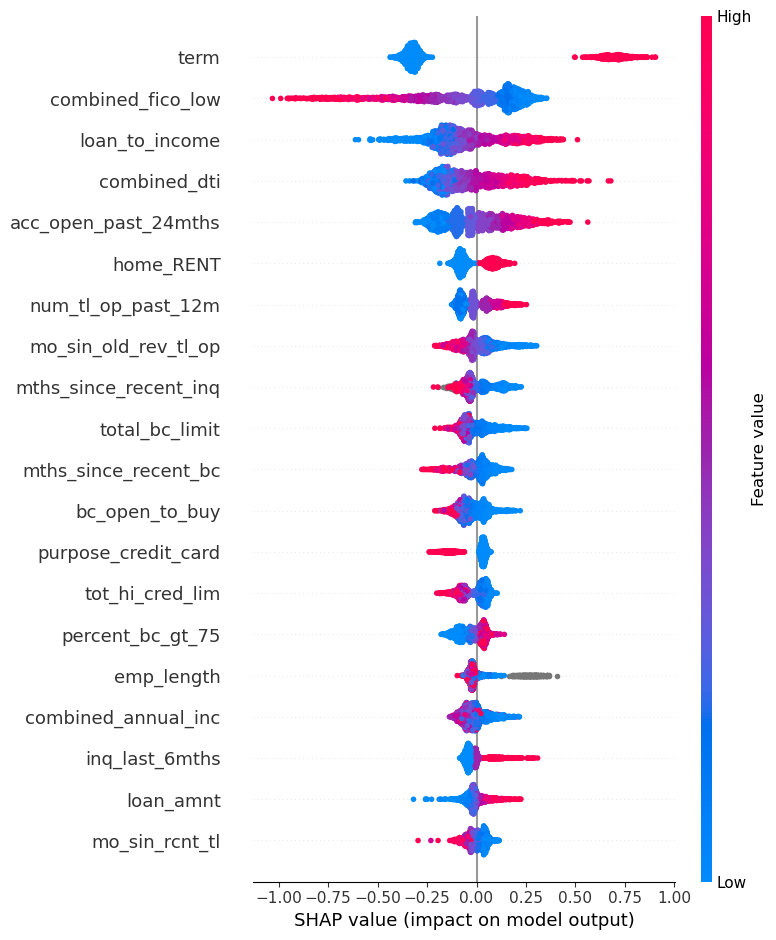

In [262]:
shap.summary_plot(shap_values, X_sample)

In [264]:
import numpy as np

mean_abs_shap = np.abs(shap_values).mean(axis=0)
importance_df = pd.DataFrame({
    'feature': X_sample.columns,
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=False)

print(importance_df.head(20))

                   feature  mean_abs_shap
2                     term       0.415438
75       combined_fico_low       0.225833
146         loan_to_income       0.157451
74            combined_dti       0.140929
35    acc_open_past_24mths       0.139904
82               home_RENT       0.081340
63      num_tl_op_past_12m       0.071062
42    mo_sin_old_rev_tl_op       0.067300
48   mths_since_recent_inq       0.064106
70          total_bc_limit       0.059247
46    mths_since_recent_bc       0.057693
37          bc_open_to_buy       0.057044
83     purpose_credit_card       0.055170
68         tot_hi_cred_lim       0.053802
65        percent_bc_gt_75       0.053005
3               emp_length       0.047526
73     combined_annual_inc       0.046893
6           inq_last_6mths       0.043650
0                loan_amnt       0.038996
44          mo_sin_rcnt_tl       0.036021


In [266]:
print(importance_df[importance_df['feature'].isin(['avg_revol_balance', 'open_to_total_acc', 'has_delinquency', 'has_severe_delinquency', 'accounts_per_credit_year'])])


                      feature  mean_abs_shap
148         open_to_total_acc       0.024622
152  accounts_per_credit_year       0.017389
147         avg_revol_balance       0.008544
149           has_delinquency       0.000000
150    has_severe_delinquency       0.000000


In [268]:

from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import average_precision_score, roc_auc_score, brier_score_loss

# 1. Drop the two features SHAP showed as unused
drop_cols = ['has_delinquency', 'has_severe_delinquency']
X_train2 = X_train.drop(columns=drop_cols)
X_val2 = X_val.drop(columns=drop_cols)
X_test2 = X_test.drop(columns=drop_cols)

# 2. Retrain with identical hyperparameters
model2 = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1
)
model2.fit(X_train2, y_train, eval_set=[(X_val2, y_val)], verbose=50)
print("Best iteration:", model2.best_iteration)
print("Best PR-AUC on val:", model2.best_score)

# 3. Re-calibrate (must refit — calibration maps THIS model's output distribution)
calibrated_model2 = CalibratedClassifierCV(model2, method='isotonic', cv='prefit')
calibrated_model2.fit(X_val2, y_val)

# 4. Evaluate on test — compare directly against the original model's numbers
test_probs2 = calibrated_model2.predict_proba(X_test2)[:, 1]
print("\nTest PR-AUC:", average_precision_score(y_test, test_probs2))
print("Test ROC-AUC:", roc_auc_score(y_test, test_probs2))
print("Test Brier score:", brier_score_loss(y_test, test_probs2))
print("Mean predicted probability:", test_probs2.mean(), "| Actual default rate:", y_test.mean())

# 5. Re-run the cost-sensitive threshold sweep with the new probabilities
ASSUMED_LGD = 0.50
ASSUMED_PROFIT_MARGIN = 0.10
thresholds_to_test = [0.10, 0.12, 0.15, 0.18, 0.20, 0.25, 0.30]
results = []
for t in thresholds_to_test:
    preds = (test_probs2 >= t).astype(int)
    approved_mask = (preds == 0)
    ead = X_test2.loc[approved_mask, 'loan_amnt']
    actual_outcome = y_test[approved_mask]
    total_loss = (ead[actual_outcome == 1] * ASSUMED_LGD).sum()
    total_profit = (ead[actual_outcome == 0] * ASSUMED_PROFIT_MARGIN).sum()
    net = total_profit - total_loss
    results.append({'threshold': t, 'approval_rate': approved_mask.mean(), 'net': net})
print("\n", pd.DataFrame(results))

[0]	validation_0-aucpr:0.37903
[50]	validation_0-aucpr:0.41171
[100]	validation_0-aucpr:0.42361
[150]	validation_0-aucpr:0.42866
[200]	validation_0-aucpr:0.43118
[250]	validation_0-aucpr:0.43285
[300]	validation_0-aucpr:0.43398
[350]	validation_0-aucpr:0.43447
[400]	validation_0-aucpr:0.43508
[450]	validation_0-aucpr:0.43517
[473]	validation_0-aucpr:0.43506
Best iteration: 423
Best PR-AUC on val: 0.4352232940254439

Test PR-AUC: 0.4132072081921982
Test ROC-AUC: 0.7112620130103448
Test Brier score: 0.1598556911866252
Mean predicted probability: 0.22615535454274038 | Actual default rate: 0.23132984095298278

    threshold  approval_rate         net
0       0.10       0.198918  23921497.5
1       0.12       0.255308  26726617.5
2       0.15       0.342137  28175827.5
3       0.18       0.424537  26869792.5
4       0.20       0.476338  24748552.5
5       0.25       0.626880  11568102.5
6       0.30       0.738432  -8382115.0


In [270]:
row_probs = model.predict_proba(X_sample)[:, 1]
top_risk_idx = row_probs.argmax()  # position within X_sample, 0-indexed

base_value = explainer.expected_value
row_shap = shap_values[top_risk_idx]
row_features = X_sample.iloc[top_risk_idx]

explanation_df = pd.DataFrame({
    'feature': X_sample.columns,
    'value': row_features.values,
    'shap_contribution': row_shap
}).sort_values('shap_contribution', key=abs, ascending=False)

print(f"Base value (average prediction, log-odds): {base_value:.4f}")
print(f"This applicant's raw model output: {base_value + row_shap.sum():.4f}")
print(f"This applicant's predicted probability: {row_probs[top_risk_idx]:.4f}")
print(f"\nTop 10 contributing features:\n")
print(explanation_df.head(10).to_string(index=False))

Base value (average prediction, log-odds): -0.0000
This applicant's raw model output: 2.5351
This applicant's predicted probability: 0.9266

Top 10 contributing features:

             feature     value  shap_contribution
                term        60           0.791874
acc_open_past_24mths      16.0           0.436260
        combined_dti      32.3           0.242874
mo_sin_old_rev_tl_op      34.0           0.180905
      loan_to_income  0.303233           0.165828
           home_RENT      True           0.110488
            state_NY      True           0.091040
       purpose_other      True           0.083316
   open_to_total_acc  0.642857           0.070065
 num_rev_tl_bal_gt_0      11.0           0.069684


In [278]:

!pip install mlflow
import mlflow
import mlflow.xgboost

mlflow.set_experiment("lending-club-credit-risk")

# Run 1: original model (153 features), for comparison
with mlflow.start_run(run_name="baseline_153_features"):
    mlflow.log_param("n_features", X_train.shape[1])
    mlflow.log_param("n_estimators", 1000)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("max_depth", 6)
    mlflow.log_param("scale_pos_weight", scale_pos_weight)
    mlflow.log_param("best_iteration", model.best_iteration)

    mlflow.log_metric("val_pr_auc", model.best_score)
    mlflow.log_metric("test_pr_auc", average_precision_score(y_test, calibrated_test_probs))
    mlflow.log_metric("test_roc_auc", roc_auc_score(y_test, calibrated_test_probs))
    mlflow.log_metric("test_brier_score", brier_score_loss(y_test, calibrated_test_probs))

    mlflow.xgboost.log_model(model, "model")


     ---------------------------------------- 0.0/49.7 kB ? eta -:--:--
     -------- ------------------------------- 10.2/49.7 kB ? eta -:--:--
     --------------- ---------------------- 20.5/49.7 kB 330.3 kB/s eta 0:00:01
     ------------------------------- ------ 41.0/49.7 kB 245.8 kB/s eta 0:00:01
     -------------------------------------- 49.7/49.7 kB 253.2 kB/s eta 0:00:00
     ---------------------------------------- 0.0/50.5 kB ? eta -:--:--
     ------------------------------ ------- 41.0/50.5 kB 991.0 kB/s eta 0:00:01
     -------------------------------------- 50.5/50.5 kB 857.3 kB/s eta 0:00:00
     ---------------------------------------- 0.0/44.0 kB ? eta -:--:--
     ---------------------------------------- 44.0/44.0 kB 1.1 MB/s eta 0:00:00
     ---------------------------------------- 0.0/43.3 kB ? eta -:--:--
     ---------------------------------------- 0.0/43.3 kB ? eta -:--:--
     ---------------------------------------- 0.0/43.3 kB ? eta -:--:--
     ----------

  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pandas-profiling 3.2.0 requires visions[type_image_path]==0.7.4, but you have visions 0.8.1 which is incompatible.
pyopenssl 24.0.0 requires cryptography<43,>=41.0.5, but you have cryptography 49.0.0 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
ydata-profiling 4.18.0 requires scipy<1.17,>=1.8, but you have scipy 1.17.1 which is incompatible.
2026/08/14 00:42:43 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/08/14 00:42:44 INFO mlflow.store.db.utils: Updating database tables
2026/08/14 00:42:59 INFO mlflow.tracking.fluent: Experiment with name 'lending-club-credit-risk' does not exist

In [280]:
with mlflow.start_run(run_name="pruned_149_features_final"):
    mlflow.log_param("n_features", X_train2.shape[1])
    mlflow.log_param("n_estimators", 1000)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("max_depth", 6)
    mlflow.log_param("scale_pos_weight", scale_pos_weight)
    mlflow.log_param("best_iteration", model2.best_iteration)
    mlflow.log_param("dropped_features", "has_delinquency, has_severe_delinquency")

    mlflow.log_metric("val_pr_auc", model2.best_score)
    mlflow.log_metric("test_pr_auc", average_precision_score(y_test, test_probs2))
    mlflow.log_metric("test_roc_auc", roc_auc_score(y_test, test_probs2))
    mlflow.log_metric("test_brier_score", brier_score_loss(y_test, test_probs2))

    mlflow.log_param("assumed_lgd", 0.50)
    mlflow.log_param("assumed_profit_margin", 0.10)
    mlflow.log_metric("f1_threshold", 0.4768)
    mlflow.log_metric("f1_threshold_net_profit", -88721445.0)
    mlflow.log_metric("profit_optimal_threshold", 0.15)
    mlflow.log_metric("profit_optimal_net_profit", 28175827.5)

    mlflow.xgboost.log_model(model2, "model")

2026/08/14 00:45:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [282]:
import os
print(os.getcwd())

import mlflow
print(mlflow.get_tracking_uri())

D:\Lending
sqlite:///D:/Lending/mlflow.db


In [284]:
import joblib

joblib.dump({
    'train_df': train_df, 'val_df': val_df, 'test_df': test_df,
    'X_train': X_train, 'X_val': X_val, 'X_test': X_test,
    'y_train': y_train, 'y_val': y_val, 'y_test': y_test,
    'scale_pos_weight': scale_pos_weight,
    'model2': model2, 'calibrated_model2': calibrated_model2,
}, 'D:/Lending/session_state.joblib')

print("saved")

saved
